In [16]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from disk_analyzer.models import DiskDataset
from Experiments import TIMES
from PredictionsAggregator import PredictionsAggregator
import pickle

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

EXP_NUM = 46
RES_FOLDER = os.path.join("Artifacts", f"Exp_{EXP_NUM}")
MODELS_FOLDER = os.path.join(RES_FOLDER, "models")
BATCH_SIZE = 1024
DATA = 'Preprocessed/30_10_test_preprocessed.csv'

In [17]:
with open(os.path.join(MODELS_FOLDER, '4_SP_model.pkl'), 'rb') as f:
    model = pickle.load(f)

In [18]:
dl = DataLoader(dataset = DiskDataset('score', [DATA]),
        batch_size = BATCH_SIZE)

In [19]:
df_test = pd.read_csv(DATA)
df_test = df_test[df_test['time'] != df_test['max_lifetime']]

In [20]:
AGG_MODE = 't_dist'
AGG_WEIGHT = 0.1
pred_agg = PredictionsAggregator(mode=AGG_MODE, weight=AGG_WEIGHT)
extended_times = pred_agg.get_extended_times(df_test, times = TIMES)
X_pred, X_gt = model.predict(dl, times=TIMES)

  0%|          | 0/43 [00:00<?, ?it/s]

100%|██████████| 43/43 [00:40<00:00,  1.06it/s]


In [21]:
def plot_agg_grid(X_pred, X_gt, serial_nums, times, agg_tuples, agg_observ):
    '''
    X_pred - датафрейм с предсказанными функциями выживания
    X_gt - датафрейм с временем жизни и флагом цензурирования
    serial_nums - список из 4 серийных номеров
    times - временная шкала
    agg_tuples - список кортежей (agg_mode, weight, n_agg)
    agg_observ - порядковый номер наблюдения к которому агрегируемся
    '''
    _, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.ravel()
    
    for i, serial_num in enumerate(serial_nums):
        X_trunc = X_pred[X_pred['serial_number'] == serial_num]
        X_gt_trunc = X_gt[X_gt['serial_number'] == serial_num]
        event = X_gt_trunc.iloc[agg_observ, -1]
        duration = X_gt_trunc.iloc[agg_observ, -2]
        
        for (agg_mode, weight, n_agg) in agg_tuples:
            X_cur_pred = X_trunc.head(agg_observ).tail(n_agg)
            pred_agg = PredictionsAggregator(mode=agg_mode, weight=weight)
            cur_timeshift = X_cur_pred.groupby('serial_number')['time'].transform('max') - X_cur_pred['time']
            pred = pred_agg.predict(X_cur_pred, times=times, timeshift=cur_timeshift)
            
            label = f"{agg_mode} (w={weight}, n={n_agg})"
            sns.lineplot(x=times, 
                        y=pred.drop(columns=['serial_number', 'time']).iloc[0], 
                        label=label,
                        linewidth=2,
                        ax=axes[i])
        
        event_color = 'r' if event else 'b'
        axes[i].axvline(x=duration, color=event_color, linestyle='--', linewidth=2)
        axes[i].set_title(f'Device {serial_num}', fontsize=12)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
        axes[i].get_legend().remove()
    
    plt.tight_layout()
    plt.show()

In [22]:
X_pred[X_gt['failure'] == 0][X_pred[X_gt['failure'] == 0][20] > 0.9]

,serial_number,time,0,1,2,3,4,5,6,7,...,720,721,722,723,724,725,726,727,728,729
1,MK0331YHGPUNJA,444,0.999982,0.999968,0.999891,0.999815,0.999802,0.999787,0.997757,0.997754,...,0.949300,0.949190,0.949176,0.949058,0.949042,0.949024,0.949017,0.948928,0.948911,0.948592
2,MJ0351YNGA61KA,122,0.999968,0.999946,0.999816,0.999717,0.999688,0.999667,0.995423,0.995413,...,0.933547,0.933399,0.933379,0.933244,0.933214,0.933181,0.933171,0.933011,0.932992,0.932503
4,MK0303YHGLLJWC,326,0.999984,0.999969,0.999887,0.999811,0.999794,0.999772,0.997390,0.997387,...,0.943128,0.943043,0.943028,0.942900,0.942879,0.942857,0.942849,0.942753,0.942738,0.942301
5,PL2331LAGSV30J,11,0.999896,0.999830,0.999463,0.999238,0.999097,0.999022,0.970879,0.970788,...,0.695405,0.694924,0.694892,0.694682,0.694542,0.694327,0.694274,0.693637,0.693583,0.691835
7,MJ0351YNG9KTBA,376,0.999980,0.999967,0.999895,0.999824,0.999810,0.999795,0.997860,0.997856,...,0.962336,0.962235,0.962222,0.962136,0.962118,0.962102,0.962095,0.962008,0.961996,0.961713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43059,MJ1311YNG5JGSA,0,0.999979,0.999962,0.999857,0.999787,0.999765,0.999746,0.996500,0.996494,...,0.942559,0.942432,0.942415,0.942287,0.942264,0.942235,0.942228,0.942099,0.942082,0.941683
43060,JK11A8B9J2D87F,223,0.999912,0.999831,0.999672,0.999433,0.999398,0.999326,0.996553,0.996544,...,0.896872,0.896746,0.896720,0.896484,0.896442,0.896420,0.896362,0.896199,0.896163,0.895683
43061,MJ0351YNG9VRUA,0,0.999967,0.999940,0.999785,0.999650,0.999607,0.999575,0.993335,0.993323,...,0.913087,0.912931,0.912905,0.912753,0.912709,0.912662,0.912647,0.912445,0.912424,0.911692
43063,JK1101B9GDZJEF,124,0.999886,0.999776,0.999553,0.998742,0.998691,0.998563,0.988371,0.988358,...,0.736767,0.736474,0.736363,0.735778,0.735673,0.735632,0.735559,0.735207,0.735161,0.733704


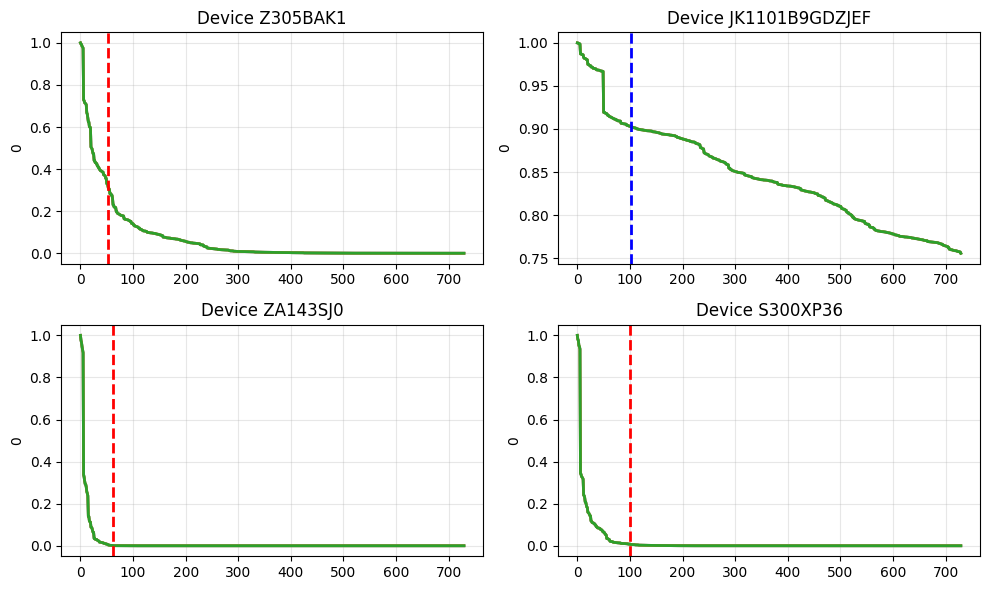

In [23]:
# disks = ['5732PE2OT', 'S300Z5WC', '13H87YWAS', 'JK1101B8JMWZSZ']
# disks = ['JK11A8B9J67Z0F', 'PL1331LAGS94VH', 'ZA143SJ0', 'S300XP36']
disks = ['Z305BAK1', 'JK1101B9GDZJEF', 'ZA143SJ0', 'S300XP36']

t_dist_scenarios = [('t_dist', 1, 1), ('t_dist', 0.1, 1), ('t_dist', 100, 1)]
plot_agg_grid(X_pred, X_gt, serial_nums = disks, times = TIMES, agg_tuples = t_dist_scenarios, agg_observ= 1)
# plot_agg_for_observ(X_pred, X_gt, serial_num='5732PE2OT', times = TIMES, agg_tuples = t_dist_scenarios, agg_observ= 5)

In [24]:
X_pred_alpha = X_pred.copy()
MAX_CLIP = 1
POW_SCALE = (-max(TIMES) * MAX_CLIP) / np.log(0.01)
print(f'POW_SCALE > 1/{POW_SCALE}')
X_pred_alpha.iloc[:,2:] = np.power(X_pred_alpha.iloc[:,2:], 1/10)

POW_SCALE > 1/158.3003386537353


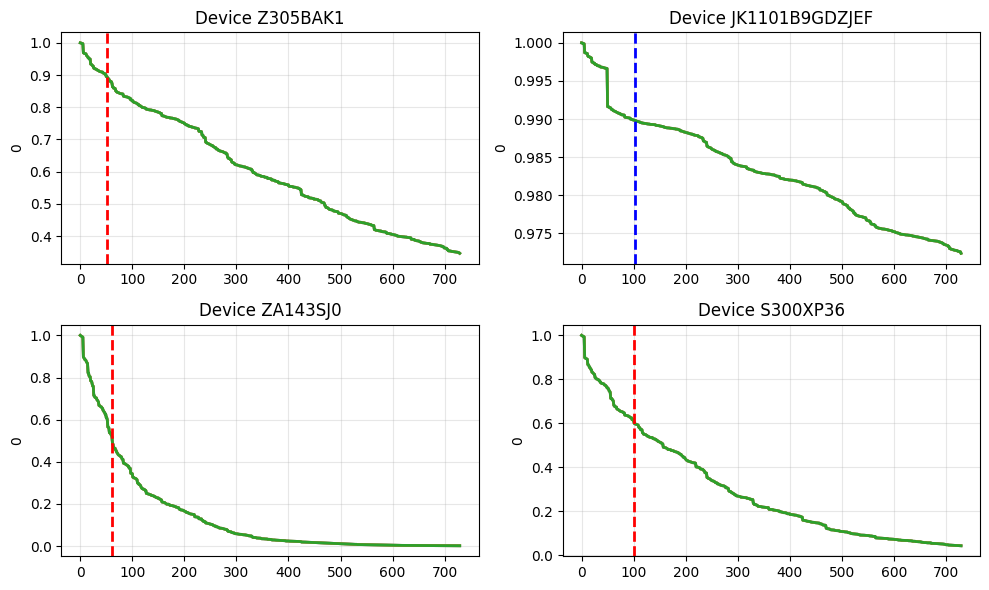

In [25]:
n_dist_scenarios = [('n_dist', 0.1, 1), ('n_dist', 0.5, 1), ('n_dist', 0.9, 1)]
plot_agg_grid(X_pred_alpha, X_gt, serial_nums = disks, times = TIMES, agg_tuples = n_dist_scenarios, agg_observ = 1)
# plot_agg_for_observ(X_pred, X_gt, serial_num='13H87YWAS', times = TIMES, agg_tuples = n_dist_scenarios, agg_observ= 5)

IndexError: index 10 is out of bounds for axis 0 with size 10

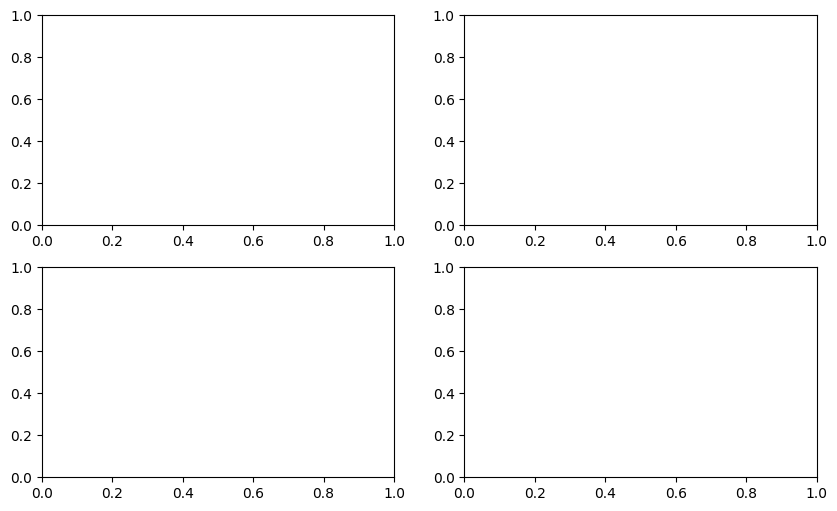

In [26]:
geom_scenarios = [('geom', 0.1, 5), ('geom', 0.5, 5), ('geom', 0.9, 5)]
plot_agg_grid(X_pred, X_gt, serial_nums = disks, times = TIMES, agg_tuples = geom_scenarios, agg_observ= 10)
# plot_agg_for_observ(X_pred, X_gt, serial_num='13H87YWAS', times = TIMES, agg_tuples = n_dist_scenarios, agg_observ= 5)
# 5732PE2OT
# 13H87YWAS

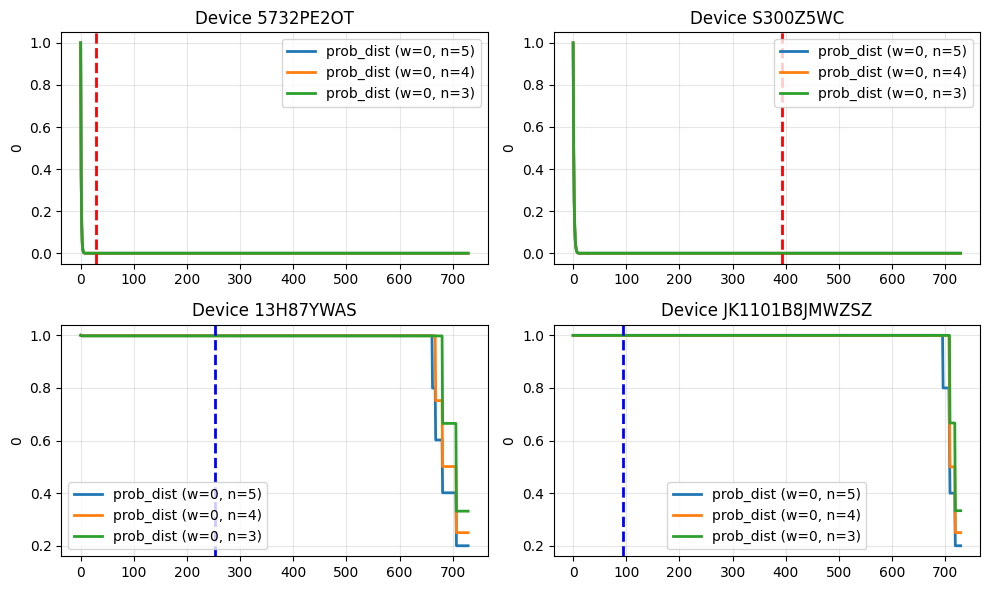

In [ ]:
prob_scenarios = [('prob_dist', 0, 5), ('prob_dist', 0, 4), ('prob_dist', 0, 3)]
plot_agg_grid(X_pred, X_gt, serial_nums = disks, times = TIMES, agg_tuples = prob_scenarios, agg_observ= 10)
# plot_agg_for_observ(X_pred, X_gt, serial_num='13H87YWAS', times = TIMES, agg_tuples = prob_scenarios, agg_observ= 5)
# 5732PE2OT
# 13H87YWAS

In [ ]:
only_failure = X_gt[(X_gt['failure'] == 1)]
only_failure[only_failure['time'] == only_failure.groupby('serial_number')['time'].transform('max')]


,serial_number,time,duration,failure
148,5732PE2OT,719,1,True
827,96ICTBQIT,416,1,True
852,9QM04GKZ,505,3,True
2513,JK1101B9J301EF,178,1,True
3347,JK1101B9JP60TU,8,1,True
...,...,...,...,...
106568,ZA189K7R,617,1,True
106599,ZA18BLFG,626,1,True
106624,ZA18BLNT,675,3,True
106633,ZCH04Y2W,677,1,True


In [ ]:
(X_gt[X_gt['failure'] == 1]['duration'] - X_predicted_duration).median()

112.60177783010822

In [ ]:
(X_gt[X_gt['failure'] == 1]['duration'] - X_no_agg_predict).mean()


163.160056689063

# Metriki s axis

In [ ]:
from lifelines.utils import concordance_index  # type: ignore
from survivors.metrics import ibs_remain
import pandas as pd

def bal_ibs_remain(survival_train, survival_test, estimate, times, axis=-1):
    """ IBS with equal impact of each event type and partial observation with controlled quantity """
    ibs_event = ibs_remain(survival_train, survival_test[survival_test["event"]],
                            estimate[survival_test["event"]], times, axis=axis)
    ibs_cens = ibs_remain(survival_train, survival_test[~survival_test["event"]],
                            estimate[~survival_test["event"]], times, axis=axis)
    return (ibs_event + ibs_cens)/2

def get_ci_ibs_ibs_bal(model, df_pred: pd.DataFrame, df_gt: pd.DataFrame, times: np.ndarray, axis=-1):
    """Calculate Concordance Index (CI) and Integrated Brier Score (IBS).

    Args:
        model: The trained model used for predictions.
        df_pred (pd.DataFrame): DataFrame containing predicted survival functions.
        df_gt (pd.DataFrame): DataFrame containing ground truth durations and event indicators.
        times (np.ndarray): Array of time points for evaluation.

    Returns:
        Tuple[float, float, float]: Concordance Index (CI), Integrated Brier Score (IBS) and balanced IBS.
    """
    survival_test = pd.DataFrame()
    survival_test['event'] = df_gt['failure'].astype(bool)
    survival_test['duration'] = df_gt['duration']

    lifetime_pred = model.get_expected_time_by_predictions(df_pred, times)

    ci = concordance_index(df_gt['duration'], lifetime_pred, df_gt['failure'])

    survival_estim = df_pred.drop(['serial_number', 'time'], axis='columns')
    ibs = ibs_remain(
        None,
        survival_test.to_records(index=False),
        survival_estim,
        times,
        axis=axis
    )

    ibs_bal = bal_ibs_remain(
        None,
        survival_test.to_records(index=False),
        survival_estim,
        times,
        axis=-1
    )

    return ci, ibs, ibs_bal

In [ ]:
ci_orig, ibs_orig, ibs_bal_orig = get_ci_ibs_ibs_bal(model, X_pred, X_gt, TIMES)

In [ ]:
ci_orig, ibs_orig, ibs_bal_orig

(0.8288555896768071, 0.15351459947245033, 0.1937280674273985)

In [ ]:
X_pred_alpha = X_pred.copy()
X_pred_alpha.iloc[:,2:] = np.power(X_pred_alpha.iloc[:,2:], 1/100)

In [ ]:
ci, ibs, ibs_bal = get_ci_ibs_ibs_bal(model, X_pred_alpha, X_gt, TIMES, axis = -1)
# _, ibs_along_time, ibs_bal_time = get_ci_ibs_ibs_bal(model, X_pred_alpha, X_gt, TIMES, axis = 1)
# _, ibs_along_obs, ibs_bal_obs = get_ci_ibs_ibs_bal(model, X_pred_alpha, X_gt, TIMES, axis = 0)


In [ ]:
ci, ibs, ibs_bal

(0.8287200037765029, 0.3685673852528441, 0.3728607962522196)

# Graphiki korrektirovki

In [ ]:
import seaborn as sns
inv_alpha_grid = [1, 10, 50, 100, 500, 1000]
df_alpha = pd.DataFrame(columns = ['inv_alpha', 'ci', 'ibs', 'ibs_bal'])
for inv_alpha in inv_alpha_grid:
    cur_X_pred_alpha = X_pred.copy()
    cur_X_pred_alpha.iloc[:,2:] = np.power(cur_X_pred_alpha.iloc[:,2:], 1/inv_alpha)
    ci, ibs, ibs_bal = get_ci_ibs_ibs_bal(model, cur_X_pred_alpha, X_gt, TIMES, axis = -1)
    df_alpha.loc[len(df_alpha)] = {"inv_alpha": inv_alpha,
                                        "ci":ci,
                                        "ibs": ibs,
                                        "ibs_bal": ibs_bal}

max_clip: 1, pow_scale: 158.3003386537353


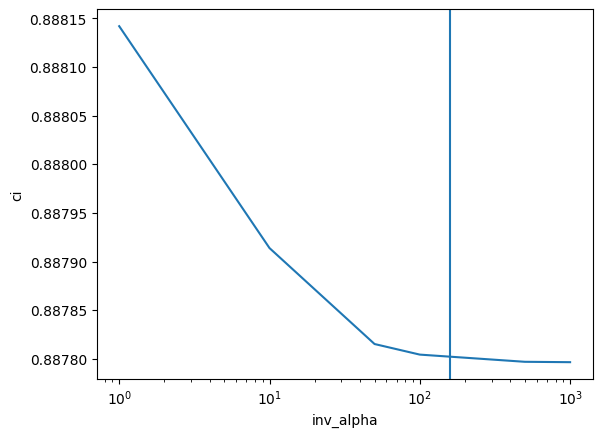

In [ ]:
ax = sns.lineplot(df_alpha, x = 'inv_alpha', y = 'ci').set(xscale='log')
plt.axvline(POW_SCALE)
print(f'max_clip: {MAX_CLIP}, pow_scale: {POW_SCALE}')

max_clip: 1, pow_scale: 158.3003386537353


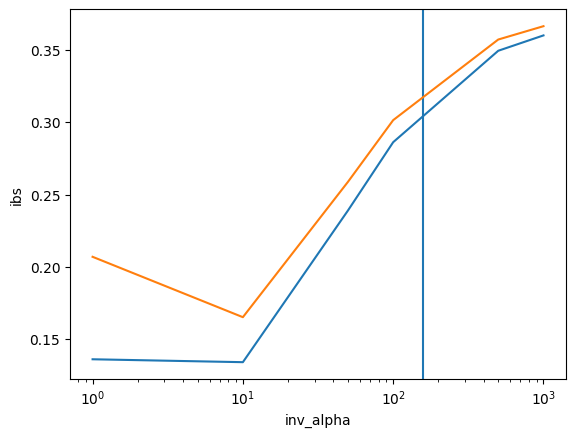

In [ ]:
plt.axvline(POW_SCALE)
sns.lineplot(df_alpha, x = 'inv_alpha', y = 'ibs').set(xscale='log')
sns.lineplot(df_alpha, x = 'inv_alpha', y = 'ibs_bal').set(xscale='log')
print(f'max_clip: {MAX_CLIP}, pow_scale: {POW_SCALE}')
